## CMPINF 2100 Week 06
### Creating histgrams in Pandas and Seaborn

## Overview

We **CANNOT** use bar charts with continuous variables! That is because bar charts COUNT the number of rows for each unique value continuous variables typically have FAR TOO MANY unique values to actually count and visualize with bar charts! Instead, we want to see the intervals where the variale is CONCENTRATED vs the intervals where the variable is NOT concentrated!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

### Read data

In [2]:
gap_url = 'https://raw.githubusercontent.com/chendaniely/pandas_for_everyone/master/data/gapminder.tsv'

In [5]:
gap_df = pd.read_csv(gap_url, sep='\t' )

In [6]:
gap_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 80.0+ KB


In [7]:
penguins = sns.load_dataset('penguins')

In [8]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


## Gapminder data

In [9]:
gap_df.dtypes

country       object
continent     object
year           int64
lifeExp      float64
pop            int64
gdpPercap    float64
dtype: object

In [10]:
gap_df.nunique()

country       142
continent       5
year           12
lifeExp      1626
pop          1704
gdpPercap    1704
dtype: int64

In [12]:
gap_df.lifeExp.value_counts()

lifeExp
69.390    4
66.800    3
78.770    3
70.750    3
76.420    3
         ..
55.861    1
52.644    1
49.265    1
45.580    1
43.487    1
Name: count, Length: 1626, dtype: int64

In [13]:
gap_df.lifeExp.value_counts().value_counts()

count
1    1558
2      59
3       8
4       1
Name: count, dtype: int64

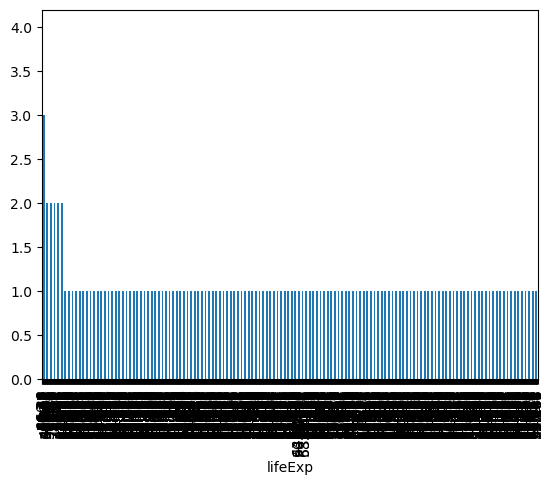

In [16]:
fig, ax = plt.subplots()

gap_df.lifeExp.value_counts().plot( kind='bar', ax=ax )

plt.show()

We need to use a plot type that is SPECIFIC to the NUMERIC or number data type!!!

we still want to count but we cannot count the raw individual values!! Instead we need to focus on intervals!!!

Let's call a Pandas method that produces HISTOGRAMS for us.

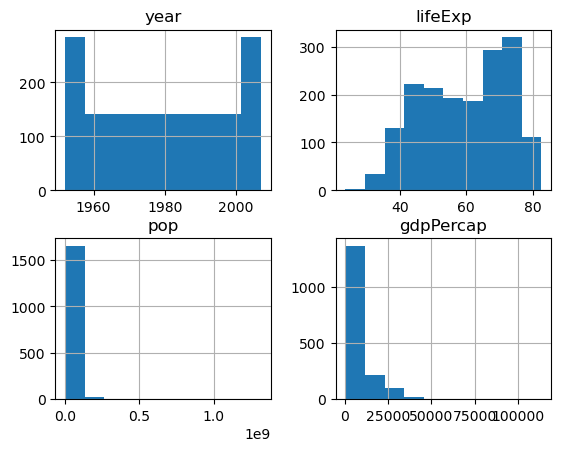

In [18]:
gap_df.hist()
plt.show()

Let's focus on a SINGLE continuous variable

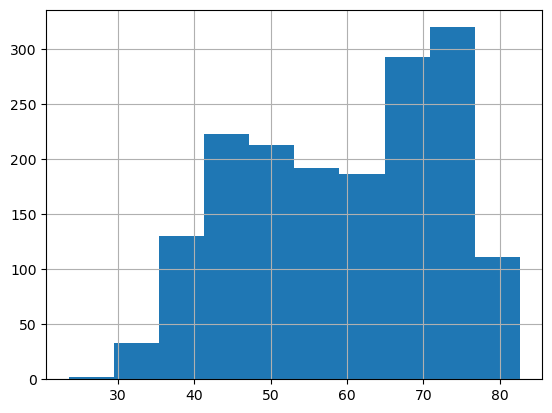

In [19]:
fig, ax = plt.subplots()

gap_df.lifeExp.hist(ax=ax)

plt.show()

Let's make the corresponding figure in Seaborn using the appropriate AXES level function.

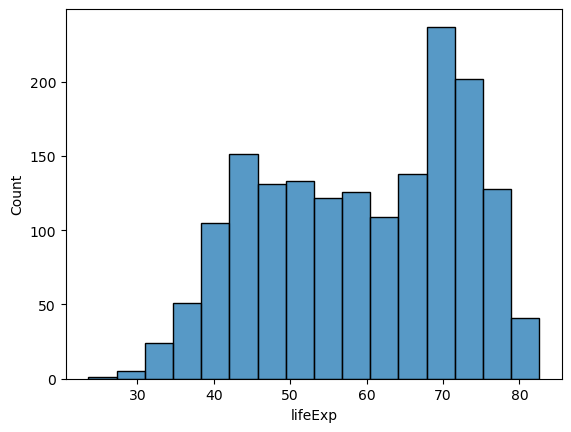

In [20]:
fig, ax = plt.subplots()

sns.histplot( data = gap_df, x='lifeExp', ax=ax )

plt.show()

Pandas by default uses 10 bins in the histogram. Let's force seaborn to also use 10 bins.

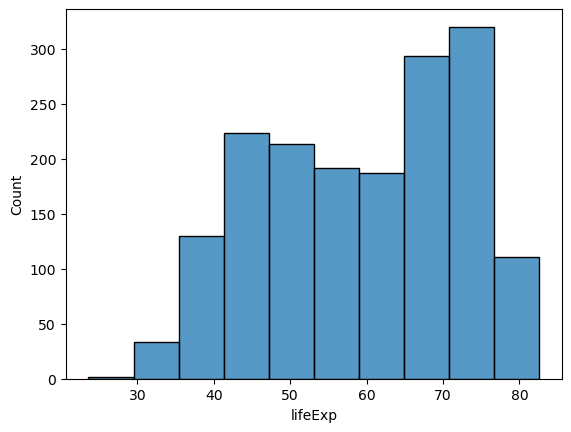

In [22]:
fig, ax = plt.subplots()

sns.histplot( data = gap_df, x='lifeExp', bins=10, ax=ax )

plt.show()

We can also create histogram using the FIGURE level function.
The bar chart figure level function was 'sns.catplot()'. The goal was to work with categorical variables. But the GOAL for visualizing the **DISTRIBUTION** of continuous variables is different from counting categorical! Thus the figure level function is different! The figure level function is 'sns.displot()'!!!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


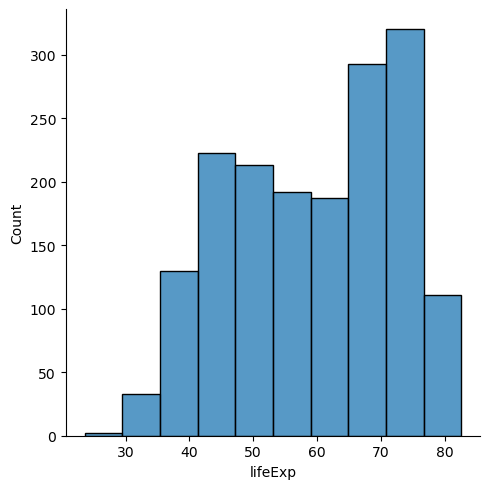

In [24]:
sns.displot( data = gap_df, x='lifeExp', kind='hist', bins=10)
plt.show()

what happens if we use fewer bins

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


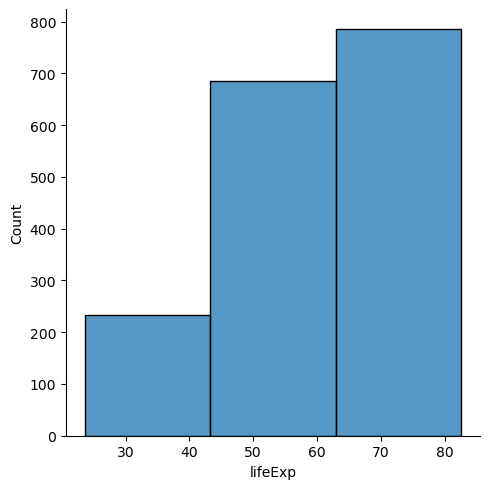

In [25]:
sns.displot( data = gap_df, x='lifeExp', kind='hist', bins=3)
plt.show()

what if we use many bins

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


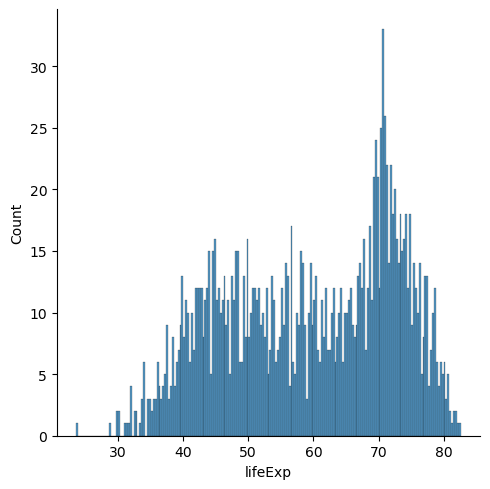

In [26]:
sns.displot( data = gap_df, x='lifeExp', kind='hist', bins=201)
plt.show()

We want just GENERAL or ROUGH ideas about how the CONCENTRATION is distributed!!

So use a moderate number of bins

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


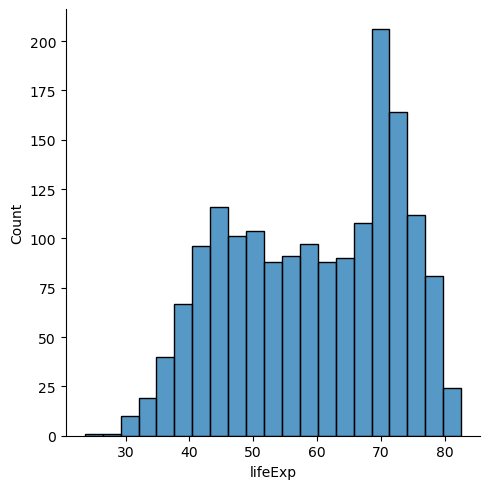

In [27]:
sns.displot( data = gap_df, x='lifeExp', kind='hist', bins=21)
plt.show()

In addition to the HISTOGRAM we could use the Kernel Density Estimate or KDE plot

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


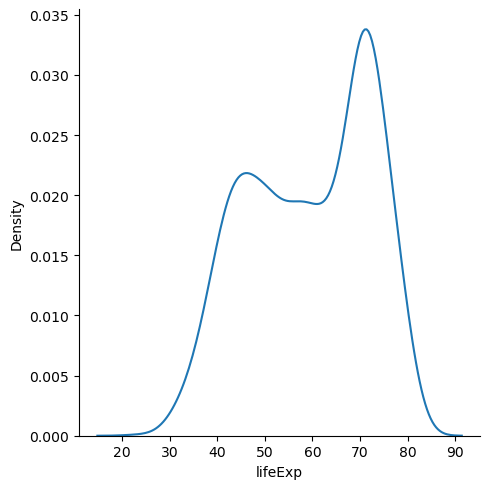

In [28]:
sns.displot(data = gap_df, x='lifeExp', kind='kde')
plt.show()

COMBINE the histogram with the default number of bins with the KDE

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


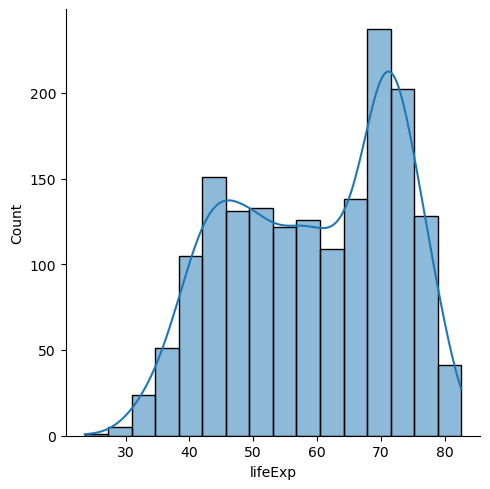

In [29]:
sns.displot( data = gap_df, x='lifeExp', kind='hist', kde=True )
plt.show()

Look at the DISTRIBUTION of the other continuous variables in gap_df

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


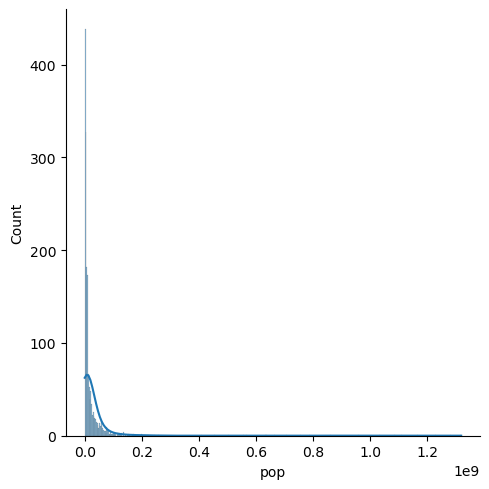

In [30]:
sns.displot( data = gap_df, x ='pop', kind='hist', kde=True)
plt.show()

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


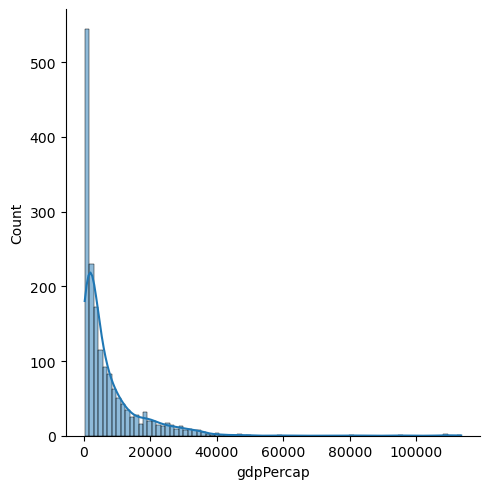

In [31]:
sns.displot( data = gap_df, x ='gdpPercap', kind='hist', kde=True)
plt.show()

## Penguins

In [32]:
penguins.dtypes

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

In [33]:
penguins.nunique()

species                3
island                 3
bill_length_mm       164
bill_depth_mm         80
flipper_length_mm     55
body_mass_g           94
sex                    2
dtype: int64

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


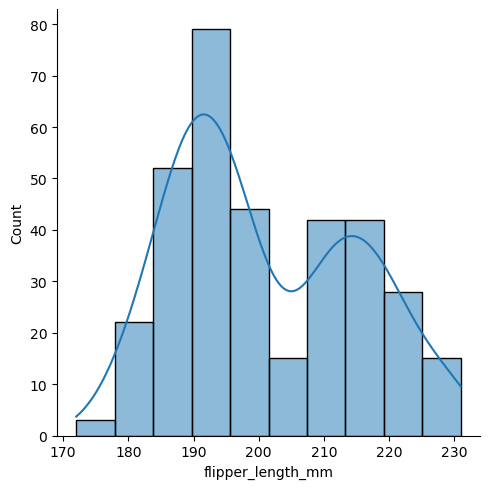

In [37]:
sns.displot( data = penguins, x='flipper_length_mm', kind='hist', kde=True)

plt.show()

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


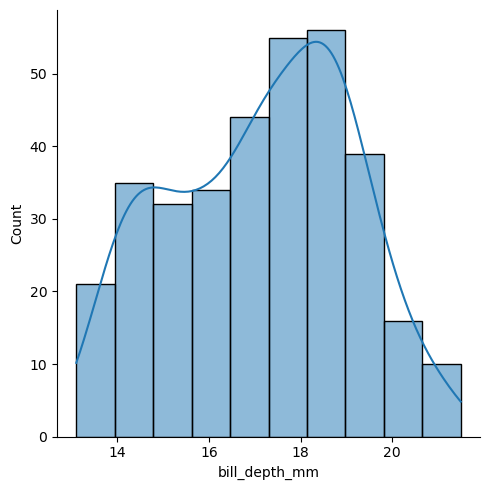

In [39]:
sns.displot(data = penguins, x='bill_depth_mm', kind='hist', kde=True)

plt.show()